In [5]:
import pathlib
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [6]:
# Path to CORDEX-Bench dataset
cordexbench_root = pathlib.Path('/gws/nopw/j04/mohc_shared/cordexbench')
print(cordexbench_root.is_dir())

True


In [7]:
# Define functions for data visualisation
def plot_predictor_map(predictor, var_name, domain, time_index=0, figsize=(8,8), cmap='viridis'):
    data_to_plot = predictor[var_name].isel(time=time_index)
    
    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS' else None
    
    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))
    
    data_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    plt.title(f'Variable {var_name} from predictor set ({domain}) for time step {time_index}')
    plt.show()

def plot_orog_map(orog, domain, figsize=(8,8), cmap='terrain'):
    data_to_plot = orog['orog']
    
    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS' else None
    
    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if (domain == 'NZ') or (domain == 'SA'):
        data_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    elif domain == 'ALPS':
        cs = ax.pcolormesh(data_to_plot['lon'], data_to_plot['lat'],
                           data_to_plot,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap)
    
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    plt.title(f'Orography ({domain})')
    plt.show()

def plot_predictand_map(predictand, var_name, domain, time_index, figsize=(8,8), cmap='viridis'):
    data_to_plot = predictand[var_name].isel(time=time_index)
    
    central_longitude = 180 if domain == 'NZ' else 0 if domain == 'ALPS' else None
    
    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if (domain == 'NZ') or (domain == 'SA'):
        data_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    elif domain == 'ALPS':
        cs = ax.pcolormesh(data_to_plot['lon'], data_to_plot['lat'],
                           data_to_plot,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap)
    
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    plt.title(f'Variable {var_name} from predictand set ({domain}) for time step {time_index}')
    plt.show()

In [8]:
# Select domain
domain = 'SA' # ALPS, NZ, SA
DATA_PATH = cordexbench_root/f'{domain}_domain'

In [9]:
# Select the training experiment
training_experiment = 'Emulator_hist_future' # ESD_pseudo_reality, Emulator_hist_future

In [10]:
# Set the period
if training_experiment == 'ESD_pseudo_reality':
    period_training = '1961-1980'
elif training_experiment == 'Emulator_hist_future':
    period_training = '1961-1980_2080-2099'
else:
    raise ValueError('Provide a valid date')

# Set the GCM
if domain == 'ALPS':
    gcm_name = 'CNRM-CM5'
elif (domain == 'NZ') or (domain == 'SA'):
    gcm_name = 'ACCESS-CM2'

In [11]:
# Load the predictor dataset
predictor_filename = f'{DATA_PATH}/train/{training_experiment}/predictors/{gcm_name}_{period_training}.nc'
predictor = xr.open_dataset(predictor_filename)
if domain == 'SA':
    predictor = predictor.drop_vars('time_bnds') # SA dataset contains time bounds which can be dropped
print(predictor)

<xarray.Dataset> Size: 224MB
Dimensions:  (time: 14600, lat: 16, lon: 16)
Coordinates:
  * time     (time) datetime64[ns] 117kB 1961-01-01T12:00:00 ... 2099-12-31T1...
  * lat      (lat) float64 128B -40.0 -38.0 -36.0 -34.0 ... -14.0 -12.0 -10.0
  * lon      (lon) float64 128B 11.0 13.0 15.0 17.0 19.0 ... 35.0 37.0 39.0 41.0
Data variables: (12/15)
    t_500    (time, lat, lon) float32 15MB ...
    t_700    (time, lat, lon) float32 15MB ...
    t_850    (time, lat, lon) float32 15MB ...
    u_500    (time, lat, lon) float32 15MB ...
    u_700    (time, lat, lon) float32 15MB ...
    u_850    (time, lat, lon) float32 15MB ...
    ...       ...
    z_500    (time, lat, lon) float32 15MB ...
    z_700    (time, lat, lon) float32 15MB ...
    z_850    (time, lat, lon) float32 15MB ...
    q_500    (time, lat, lon) float32 15MB ...
    q_700    (time, lat, lon) float32 15MB ...
    q_850    (time, lat, lon) float32 15MB ...
Attributes: (12/259)
    CDI:                  Climate Data Interfa

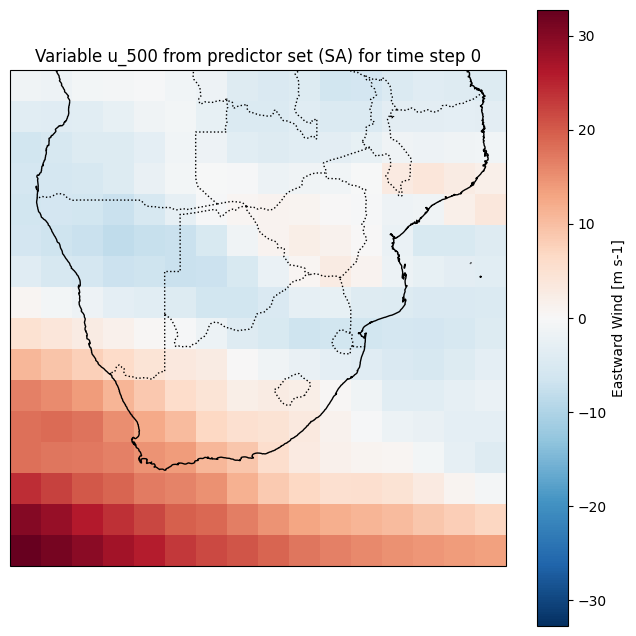

In [20]:
# Visualise predictor dataset
plot_predictor_map(predictor=predictor, var_name='u_500', domain=domain, time_index=0, cmap='RdBu_r')

In [13]:
# Load the predictands (targets) dataset
predictand_filename = f'{DATA_PATH}/train/{training_experiment}/target/pr_tasmax_{gcm_name}_{period_training}.nc'
predictand = xr.open_dataset(predictand_filename)
if domain == 'SA':
    predictand = predictand.drop_vars(['time_bnds', 'lon_bnds', 'lat_bnds', 'crs']) # SA dataset contains these additional variables which can be dropped
print(predictand)

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 14600, lat: 128, lon: 128)
Coordinates:
  * time     (time) datetime64[ns] 117kB 1961-01-01T12:00:00 ... 2099-12-31T1...
  * lat      (lat) float32 512B -34.7 -34.6 -34.5 -34.4 ... -22.2 -22.1 -22.0
  * lon      (lon) float32 512B 20.5 20.6 20.7 20.8 20.9 ... 32.9 33.0 33.1 33.2
Data variables:
    pr       (time, lat, lon) float64 2GB ...
    tasmax   (time, lat, lon) float32 957MB ...
Attributes: (12/259)
    CDI:                  Climate Data Interface version 1.9.8 (https://mpime...
    history:              Thu Sep 25 09:29:15 2025: cdo mergetime pr_tasmax_c...
    source:               CSIRO conformal-cubic model. Input file: ccam_8.km....
    Conventions:          CF-1.11
    title:                CCAM simulation data
    il:                   192
    ...                   ...
    ateb_ac_deltat:       1.0
    ateb_ac_heatcap:      10.0
    ateb_acfactor:        2.0
    ateb_alpha:           1.0
    ateb_lwintmeth:       2
    ateb_

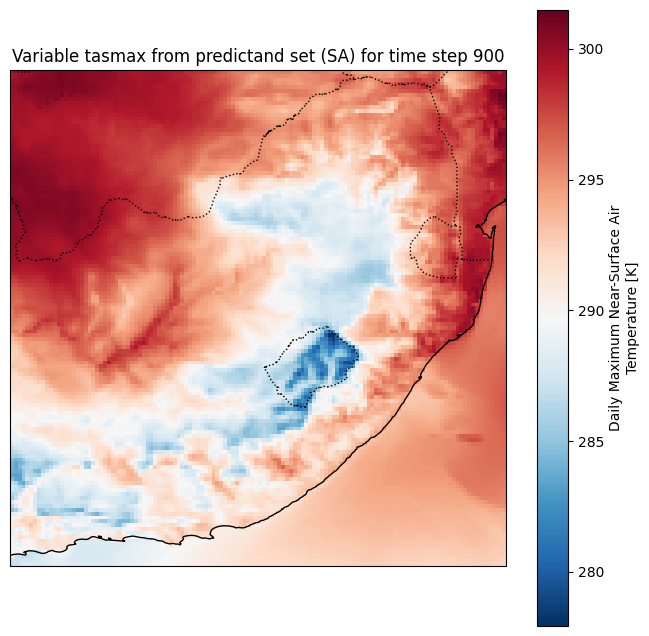

In [14]:
# Visualise predictand dataset
plot_predictand_map(predictand=predictand, var_name='tasmax', time_index=900, domain=domain, cmap='RdBu_r')

In [15]:
# For the ALPS domain, the predictands are on a curvilinear Lambert projection. The data is still suitable for model training in this format since the data remains a square array.
if domain == 'ALPS':
    predictand_tasmax_array = predictand['tasmax'].values
    plt.imshow(predictand_tasmax_array[0, :], origin='lower')
    plt.colorbar()
    plt.show()

In [16]:
# Load static fields dataset (orography). Resolution the same as the predictands. Note for SA the domain is the same as predictors, but for ALPS and NZ the domain is the same as predicands.
orog_path =  f'{DATA_PATH}/train/{training_experiment}/predictors/Static_fields.nc'
orog = xr.open_dataset(orog_path)[['orog']]
print(orog)

<xarray.Dataset> Size: 365kB
Dimensions:  (lat: 301, lon: 301)
Coordinates:
  * lat      (lat) float32 1kB -40.0 -39.9 -39.8 -39.7 ... -10.2 -10.1 -10.0
  * lon      (lon) float32 1kB 11.0 11.1 11.2 11.3 11.4 ... 40.7 40.8 40.9 41.0
Data variables:
    orog     (lat, lon) float32 362kB ...
Attributes: (12/351)
    source:               CSIRO conformal-cubic model. Input file: ccam_8.km....
    Conventions:          CF-1.11
    title:                CCAM simulation data
    history:              Created on 2025-08-28 03:23:27
    il:                   192
    kl:                   35
    ...                   ...
    zomode:               0
    zoseaice:             0.0005
    expdesc:              CCAM model run
    version:              CCAM
    modeling_realm:       atmos
    grid:                 Unrotated latitude/longitude grid interpolated from...


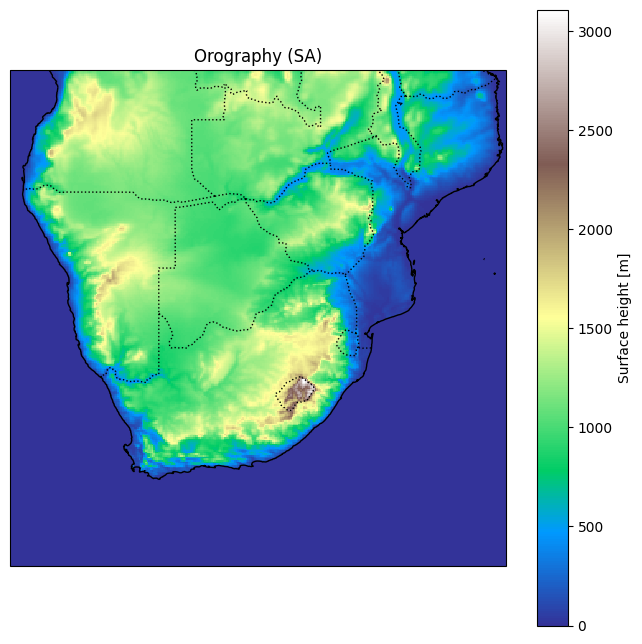

In [17]:
# Visualise orography
plot_orog_map(orog=orog, domain=domain)

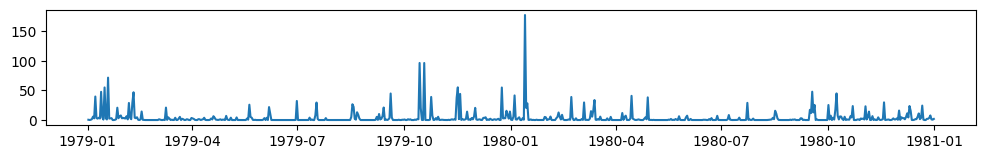

In [18]:
# Pinpoint for WITS University
lat_WITS, lon_WITS = (-26.192862028089113, 28.03044694284916)
predictand_WITS = predictand.sel(
    lat = lat_WITS,
    lon = lon_WITS,
    method = "nearest")
predictand_WITS_test = predictand_WITS.sel(time=slice("1979-01-01", "1980-12-31"))
plt.figure(figsize=(12,1.5))
plt.plot(predictand_WITS_test['time'],predictand_WITS_test['pr'])

In [ ]:
# Create netCDF files for 